# Descriptive Analysis: WritingPrompts Story Generations

- WritingPrompts (Fan et al., 2018), test split
- 200 sampled prompts
- `seed=42`


**Models:**

- Gemma: google/gemma-2-9b-it
- Llama: meta-llama/Llama-3.1-8B-Instruct
- Mistral: mistralai/Mistral-7B-Instruct-v0.3
- Qwen: Qwen/Qwen2.5-7B-Instruct

**Decoding:** `temperature=1.0`, `top_p=0.9`, `repetition_penalty=1.0` (disabled), `n=5` samples per prompt (500 stories per model)

**Reference:** all available human-written stories per prompt (`prompts_sample.jsonl`), each prompt filtered to have >=5 human references (`MIN_HUMAN_REFS=5`)

In [164]:
# Load libraries
import json
import re
import collections
import pathlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [165]:
# Plotting parameters
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# Locate the repo root regardless of the kernel's working directory
def find_repo_root(start=pathlib.Path.cwd()):
    for p in [start, *start.parents]:
        if (p / 'data_generation' / 'generations' / 'storytelling_n200').is_dir():
            return p
    raise FileNotFoundError("Could not locate 'generations/storytelling_n200' above the current directory")

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / 'data_generation' / 'generations' / 'storytelling_n200'
FIG_DIR = REPO_ROOT / 'figures' / 'storytelling'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS = {
    'gemma':   'google/gemma-2-9b-it',
    'llama':   'meta-llama/Llama-3.1-8B-Instruct',
    'mistral': 'mistralai/Mistral-7B-Instruct-v0.3',
    'qwen':    'Qwen/Qwen2.5-7B-Instruct',
}

MODEL_LABELS = {
    'gemma': 'Gemma-2-9B', 'llama': 'Llama-3.1-8B',
    'mistral': 'Mistral-7B-v0.3', 'qwen': 'Qwen2.5-7B', 'human': 'Human',
}

MODEL_COLORS = {
    'Human':            '#cb1f73',
    'Gemma-2-9B':       '#fcc72d',
    'Llama-3.1-8B':     '#ea6d3d',
    'Mistral-7B-v0.3':  '#e03a3c',
    'Qwen2.5-7B':       '#383a6b',
}

MODEL_ORDER = ['Human', 'Gemma-2-9B', 'Llama-3.1-8B', 'Mistral-7B-v0.3', 'Qwen2.5-7B']
GEN_ORDER = [m for m in MODEL_ORDER if m != 'Human']

## Load & Prepare Data

In [ ]:
# Generation configs (identical decoding params across models, saved per run)
configs = {key: json.load(open(DATA_DIR / f'config_{key}.json')) for key in MODELS}
config_overview = pd.DataFrame(configs).T[
    ['model_id', 'n_prompts', 'n_samples', 'temperature', 'top_p', 'repetition_penalty', 'max_new_tokens']
]

display(config_overview)

,model_id,n_prompts,n_samples,temperature,top_p,repetition_penalty,max_new_tokens
gemma,google/gemma-2-9b-it,200,5,1.0,0.9,1.0,1280
llama,meta-llama/Llama-3.1-8B-Instruct,200,5,1.0,0.9,1.0,1280
mistral,mistralai/Mistral-7B-Instruct-v0.3,200,5,1.0,0.9,1.0,1280
qwen,Qwen/Qwen2.5-7B-Instruct,200,5,1.0,0.9,1.0,1280


In [184]:
# Load generated stories (4 models x 200 prompts x 5 samples)
records = []
for key in MODELS:
    with open(DATA_DIR / f'writingprompts_{key}_n5.jsonl') as f:
        for line in f:
            r = json.loads(line)
            r['model_key'] = key
            records.append(r)

df_gen = pd.DataFrame(records)
df_gen['model'] = df_gen['model_key'].map(MODEL_LABELS)
df_gen['word_count'] = df_gen['story'].str.split().str.len()
df_gen['char_count'] = df_gen['story'].str.len()

print(f'Loaded {len(df_gen)} generated stories')
df_gen.head(3)

Loaded 4000 generated stories


,prompt_id,prompt,model,sample_idx,story,finish_reason,n_tokens,cjk_chars,language_ok,model_key,word_count,char_count
0,wp_0000,Turns out that the purpose of life is war. Hum...,Gemma-2-9B,0,"The news came in a government broadcast, chill...",stop,520,0,True,gemma,391,2357
1,wp_0000,Turns out that the purpose of life is war. Hum...,Gemma-2-9B,1,"The news hit like a supernova, exploding acros...",stop,580,0,True,gemma,433,2713
2,wp_0000,Turns out that the purpose of life is war. Hum...,Gemma-2-9B,2,"The message came on every screen, every phone,...",stop,585,0,True,gemma,442,2668


In [185]:
# Load human reference stories (all available references per prompt, >=5 per MIN_HUMAN_REFS)
human_records = [json.loads(l) for l in open(DATA_DIR / 'prompts_sample.jsonl')]
df_human = pd.DataFrame(human_records).explode('human_stories', ignore_index=True)
df_human['model_key'] = 'human'
df_human['model'] = 'Human'
df_human['story'] = df_human['human_stories']
df_human['word_count'] = df_human['story'].str.split().str.len()
df_human['char_count'] = df_human['story'].str.len()
df_human['prompt_word_count'] = df_human['prompt'].str.split().str.len()

refs_per_prompt = df_human.groupby('prompt_id').size()
print(f'Loaded {len(df_human)} human reference stories across {df_human.prompt_id.nunique()} prompts '
      f'(min={refs_per_prompt.min()}, mean={refs_per_prompt.mean():.1f}, max={refs_per_prompt.max()})')
df_human.head(3)

Loaded 1883 human reference stories across 200 prompts (min=5, mean=9.4, max=45)


,prompt,human_story,prompt_id,human_stories,model_key,model,story,word_count,char_count,prompt_word_count
0,Turns out that the purpose of life is war. Hum...,"Here is my first post, I have always wanted to...",wp_0000,"Here is my first post, I have always wanted to...",human,Human,"Here is my first post, I have always wanted to...",648,3553,45
1,Turns out that the purpose of life is war. Hum...,"Here is my first post, I have always wanted to...",wp_0000,`` The purpose of life is war. It has always b...,human,Human,`` The purpose of life is war. It has always b...,701,3907,45
2,Turns out that the purpose of life is war. Hum...,"Here is my first post, I have always wanted to...",wp_0000,"“ Dr. Garyson, you have five seconds to cut to...",human,Human,"“ Dr. Garyson, you have five seconds to cut to...",1059,5499,45


## Sanity Checks

In [186]:
# Every model should have exactly 5 samples for each of the 200 prompts
# All 5 sources (4 models + human) should refer to the same 200 prompts

samples_per_prompt = df_gen.groupby(['model_key', 'prompt_id']).size()
print(f'Generated stories: {len(df_gen)}  ({df_gen.model_key.nunique()} models x '
      f'{df_gen.prompt_id.nunique()} prompts x {samples_per_prompt.mean():.0f} samples)')

print(f'Samples per prompt (min / max): {samples_per_prompt.min()} / {samples_per_prompt.max()}')

human_refs_per_prompt = df_human.groupby('prompt_id').size()
print(f'Human reference stories: {len(df_human)} across {df_human.prompt_id.nunique()} prompts '
      f'(min / max per prompt: {human_refs_per_prompt.min()} / {human_refs_per_prompt.max()})')

prompt_id_sets = {key: frozenset(df_gen.loc[df_gen.model_key == key, 'prompt_id']) for key in MODELS}
prompt_id_sets['human'] = frozenset(df_human['prompt_id'])
print('All 5 sources share the same 200 prompt_ids:', len(set(prompt_id_sets.values())) == 1)

# Same prompt text across models (join key sanity check)
prompt_text = df_gen.drop_duplicates('prompt_id').set_index('prompt_id')['prompt']
human_prompt_text = df_human.drop_duplicates('prompt_id').set_index('prompt_id')['prompt']
print('Prompt text identical across generation + human files:',
      prompt_text.reindex(human_prompt_text.index).equals(human_prompt_text))

Generated stories: 4000  (4 models x 200 prompts x 5 samples)
Samples per prompt (min / max): 5 / 5
Human reference stories: 1883 across 200 prompts (min / max per prompt: 5 / 45)
All 5 sources share the same 200 prompt_ids: True
Prompt text identical across generation + human files: True


## Generation Quality Checks

Fields logged during generation: `finish_reason`, `n_tokens`, `cjk_chars`, `language_ok`. `finish_reason` (truncation) and `n_tokens` (tokenizer efficiency)

In [187]:
# Truncation: finish_reason == 'length'
finish_tab = pd.crosstab(df_gen['model'], df_gen['finish_reason']).reindex(GEN_ORDER)
finish_tab['truncated_%'] = (finish_tab.get('length', 0) / finish_tab.sum(axis=1) * 100).round(1)
display(finish_tab)

finish_reason,length,stop,truncated_%
model,,,
Gemma-2-9B,0,1000,0.0
Llama-3.1-8B,4,996,0.4
Mistral-7B-v0.3,15,985,1.5
Qwen2.5-7B,3,997,0.3


In [188]:
# Language drift: non-Latin (CJK) script detected in an otherwise English story
CJK_RANGES = [(0x4E00, 0x9FFF), (0x3040, 0x30FF), (0xAC00, 0xD7AF)]  # CJK Unified, Hiragana/Katakana, Hangul
CJK = re.compile('[' + ''.join(chr(lo) + '-' + chr(hi) for lo, hi in CJK_RANGES) + ']')

# df_gen already carries cjk_chars/language_ok logged during generation; compute the same check for Human
df_human['cjk_chars'] = df_human['story'].apply(lambda s: len(CJK.findall(s)))
df_human['language_ok'] = df_human['cjk_chars'] == 0

df_lang = pd.concat([
    df_gen[['model', 'prompt_id', 'sample_idx', 'story', 'cjk_chars', 'language_ok']],
    df_human[['model', 'prompt_id', 'story', 'cjk_chars', 'language_ok']],
], ignore_index=True)

lang_tab = df_lang.groupby('model').agg(
    non_english=('language_ok', lambda s: int((~s).sum())),
    max_cjk_chars=('cjk_chars', 'max'),
).reindex(MODEL_ORDER)
lang_tab['non_english_%'] = (lang_tab['non_english'] / df_lang.groupby('model').size().reindex(MODEL_ORDER) * 100).round(2)
display(lang_tab)

flagged = df_lang[~df_lang['language_ok']]
if len(flagged):
    print('\nFlagged stories:')
    for _, r in flagged.iterrows():
        share = r['cjk_chars'] / len(r['story'])
        ref = f"sample {int(r['sample_idx'])}" if pd.notna(r['sample_idx']) else 'reference'
        print(f"  {r['model']} / {r['prompt_id']} / {ref}: {share:.1%} CJK characters")

,non_english,max_cjk_chars,non_english_%
model,,,
Human,2,4,0.11
Gemma-2-9B,0,0,0.00
Llama-3.1-8B,0,0,0.00
Mistral-7B-v0.3,0,0,0.00
Qwen2.5-7B,6,1050,0.60



Flagged stories:
  Qwen2.5-7B / wp_0059 / sample 0: 0.1% CJK characters
  Qwen2.5-7B / wp_0127 / sample 0: 17.1% CJK characters
  Qwen2.5-7B / wp_0147 / sample 4: 18.7% CJK characters
  Qwen2.5-7B / wp_0177 / sample 3: 0.3% CJK characters
  Qwen2.5-7B / wp_0179 / sample 4: 0.1% CJK characters
  Qwen2.5-7B / wp_0190 / sample 2: 48.8% CJK characters
  Human / wp_0067 / reference: 0.1% CJK characters
  Human / wp_0082 / reference: 0.2% CJK characters


In [189]:
# Exact duplicates: identical story text sampled/referenced twice
df_dup_src = pd.concat([df_gen[['model', 'story']], df_human[['model', 'story']]], ignore_index=True)
dup_counts = df_dup_src.groupby('model')['story'].apply(lambda s: len(s) - s.nunique()).reindex(MODEL_ORDER)
dup_pct = (dup_counts / df_dup_src.groupby('model').size().reindex(MODEL_ORDER) * 100).round(2)
print('Exact duplicate stories per model:')
print(dup_counts)

Exact duplicate stories per model:
model
Human              1
Gemma-2-9B         0
Llama-3.1-8B       0
Mistral-7B-v0.3    0
Qwen2.5-7B         0
Name: story, dtype: int64


In [190]:
# Repeated openings: how concentrated are the first few words across all 500 stories per model?
def top_opening_share(stories, n_words=4):
    openings = collections.Counter(' '.join(s.split()[:n_words]) for s in stories)
    opening, count = openings.most_common(1)[0]
    return count / len(stories), opening

quality_rows = []
for key in MODELS:
    sub = df_gen[df_gen.model_key == key]
    n = len(sub)
    share, opening = top_opening_share(sub['story'])
    quality_rows.append({
        'model': MODEL_LABELS[key],
        'truncated_%': (sub['finish_reason'] == 'length').mean() * 100,
        'non_english_%': (~sub['language_ok']).mean() * 100,
        'exact_dup_%': (n - sub['story'].nunique()) / n * 100,
        'top_opening_share_%': share * 100,
        'top_opening': opening,
    })

quality_df = pd.DataFrame(quality_rows).set_index('model').reindex(GEN_ORDER)
display(quality_df.round(2))

,truncated_%,non_english_%,exact_dup_%,top_opening_share_%,top_opening
model,,,,,
Gemma-2-9B,0.0,0.0,0.0,3.1,The air hung thick
Llama-3.1-8B,0.4,0.0,0.0,1.3,I stared at the
Mistral-7B-v0.3,1.5,0.0,0.0,30.4,In the heart of
Qwen2.5-7B,0.3,0.6,0.0,4.0,In the heart of


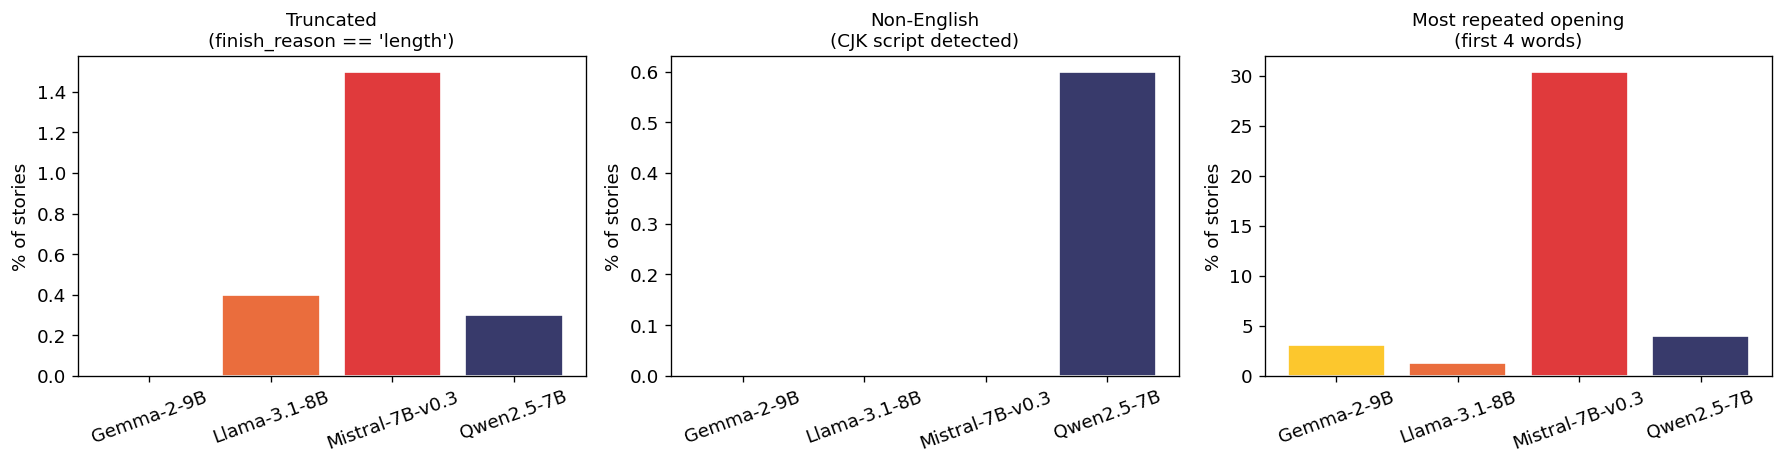

In [191]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_to_plot = ['truncated_%', 'non_english_%', 'top_opening_share_%']
titles = ["Truncated\n(finish_reason == 'length')", 'Non-English\n(CJK script detected)',
          'Most repeated opening\n(first 4 words)']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    colors = [MODEL_COLORS[m] for m in quality_df.index]
    ax.bar(quality_df.index, quality_df[metric], color=colors, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('% of stories')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_generation_quality.png', dpi=300, bbox_inches='tight')
plt.show()

## Filtering Degenerate Generations

Exclude LLM generations that were truncated (`finish_reason == 'length'`) or show language drift (`language_ok == False`), and exclude human reference stories that show language drift or are exact duplicates of another reference for the same source (counts and flagged rows printed below).

In [192]:
# --- LLM generations: exclude truncated stories and stories with language drift ---
gen_exclude_mask = (df_gen['finish_reason'] == 'length') | (~df_gen['language_ok'])

print(f'Excluding {gen_exclude_mask.sum()} of {len(df_gen)} generated stories ({gen_exclude_mask.mean():.1%}):')
print(df_gen.loc[gen_exclude_mask, ['model', 'prompt_id', 'sample_idx', 'finish_reason', 'language_ok']]
      .to_string(index=False))

df_gen_excluded = df_gen[gen_exclude_mask].copy()
df_gen = df_gen[~gen_exclude_mask].reset_index(drop=True)

print('\nRemaining generated stories per model:')
print(df_gen['model'].value_counts().reindex(GEN_ORDER))

# --- Human references: exclude stories with language drift or exact duplicates of another reference ---
human_exclude_mask = (~df_human['language_ok']) | df_human.duplicated(subset='story', keep='first')

print(f'\nExcluding {human_exclude_mask.sum()} of {len(df_human)} human reference stories '
      f'({human_exclude_mask.mean():.1%}):')
print(df_human.loc[human_exclude_mask, ['prompt_id', 'language_ok']].to_string(index=False))

df_human_excluded = df_human[human_exclude_mask].copy()
df_human = df_human[~human_exclude_mask].reset_index(drop=True)

print(f'\nRemaining human reference stories: {len(df_human)} across {df_human.prompt_id.nunique()} prompts')

Excluding 27 of 4000 generated stories (0.7%):
          model prompt_id  sample_idx finish_reason  language_ok
   Llama-3.1-8B   wp_0093           0        length         True
   Llama-3.1-8B   wp_0194           0        length         True
   Llama-3.1-8B   wp_0194           1        length         True
   Llama-3.1-8B   wp_0194           4        length         True
Mistral-7B-v0.3   wp_0008           1        length         True
Mistral-7B-v0.3   wp_0012           3        length         True
Mistral-7B-v0.3   wp_0016           0        length         True
Mistral-7B-v0.3   wp_0022           3        length         True
Mistral-7B-v0.3   wp_0037           3        length         True
Mistral-7B-v0.3   wp_0038           1        length         True
Mistral-7B-v0.3   wp_0039           3        length         True
Mistral-7B-v0.3   wp_0047           2        length         True
Mistral-7B-v0.3   wp_0062           0        length         True
Mistral-7B-v0.3   wp_0080           0      

## Length Distributions

In [193]:
df_all = pd.concat([
    df_gen[['prompt_id', 'model', 'word_count', 'char_count']],
    df_human[['prompt_id', 'model', 'word_count', 'char_count']],
], ignore_index=True)

length_summary = df_all.groupby('model')['word_count'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).reindex(MODEL_ORDER).round(1)
display(length_summary)

,count,mean,median,std,min,max
model,,,,,,
Human,1880,543.1,452.0,367.3,100,2160
Gemma-2-9B,1000,474.3,475.0,70.6,137,760
Llama-3.1-8B,996,497.4,494.0,71.3,15,1108
Mistral-7B-v0.3,985,562.0,551.0,104.5,94,929
Qwen2.5-7B,992,546.5,542.0,118.5,16,972


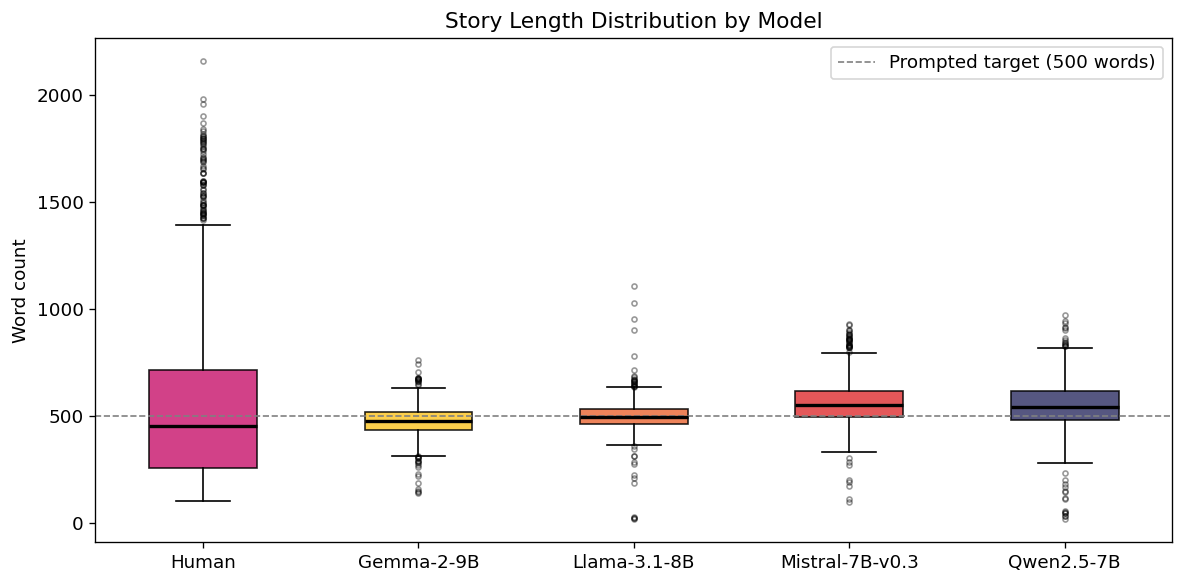

In [194]:
fig, ax = plt.subplots(figsize=(10, 5))
data = [df_all.loc[df_all.model == m, 'word_count'].values for m in MODEL_ORDER]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=MODEL_ORDER,
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, m in zip(bp['boxes'], MODEL_ORDER):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.85)

ax.axhline(500, color='gray', linestyle='--', linewidth=1, label='Prompted target (500 words)')
ax.set_ylabel('Word count')
ax.set_title('Story Length Distribution by Model')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_length_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

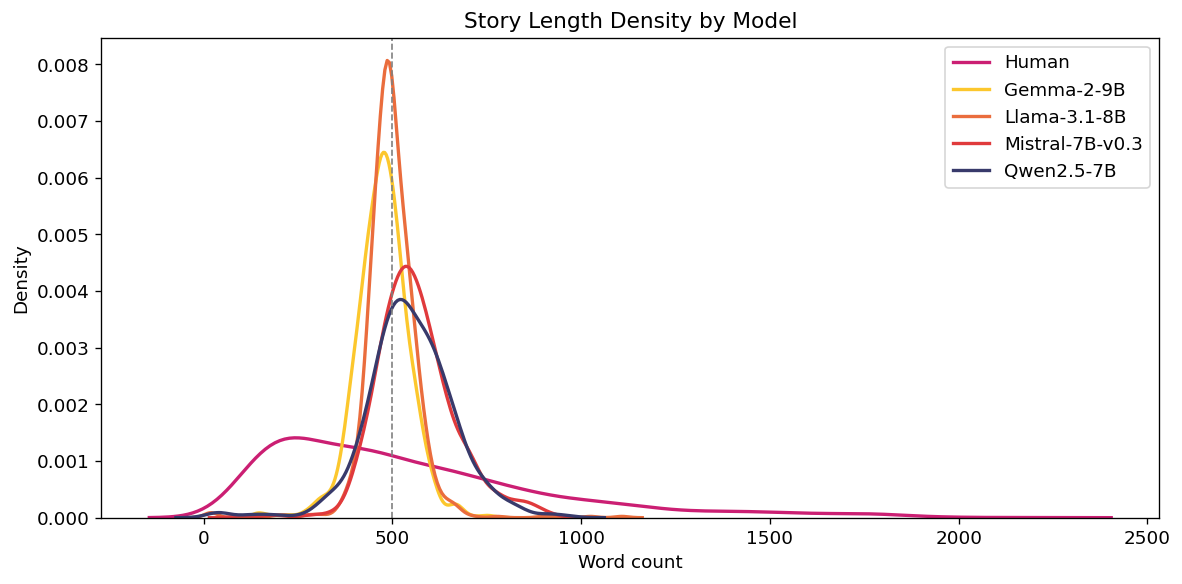

In [195]:
fig, ax = plt.subplots(figsize=(10, 5))
for m in MODEL_ORDER:
    sns.kdeplot(df_all.loc[df_all.model == m, 'word_count'], label=m,
                color=MODEL_COLORS[m], linewidth=2, ax=ax)
ax.axvline(500, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Word count')
ax.set_title('Story Length Density by Model')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_length_kde.png', dpi=300, bbox_inches='tight')
plt.show()

## Within-Prompt Length Variability

For each prompt, models produce 5 independent samples. The spread of word counts *within* the same prompt indicates
how consistently a model controls output length, as opposed to variability *across* different prompts.

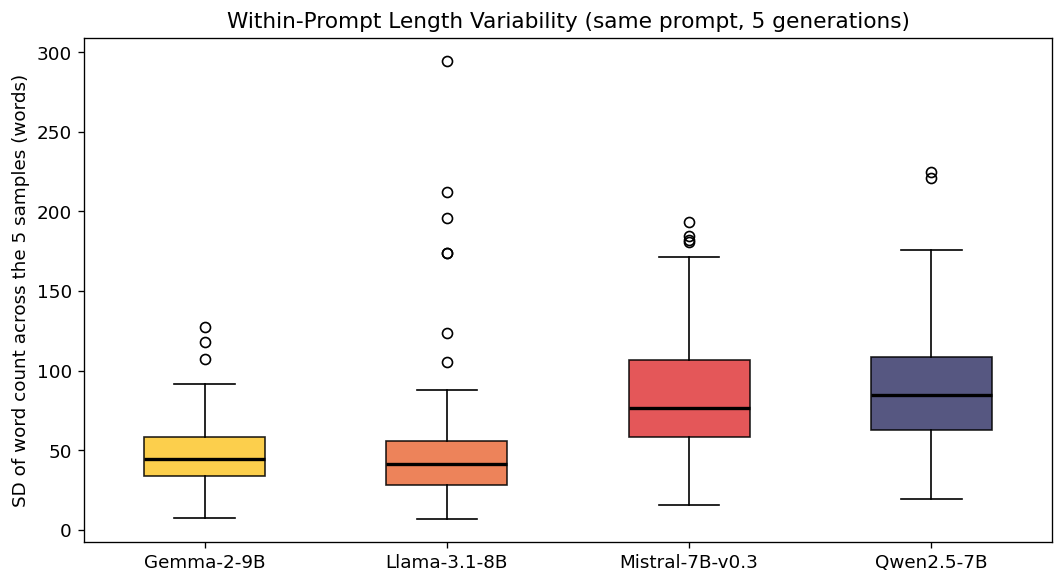

Mean within-prompt SD by model:
model
Gemma-2-9B         46.9
Llama-3.1-8B       47.2
Mistral-7B-v0.3    83.9
Qwen2.5-7B         87.3
Name: within_prompt_sd, dtype: float64


In [196]:
within_std = (df_gen.groupby(['model', 'prompt_id'])['word_count']
              .std().reset_index().rename(columns={'word_count': 'within_prompt_sd'}))

fig, ax = plt.subplots(figsize=(9, 5))
data = [within_std.loc[within_std.model == m, 'within_prompt_sd'].values for m in GEN_ORDER]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=GEN_ORDER,
                 medianprops=dict(color='black', linewidth=2))
for patch, m in zip(bp['boxes'], GEN_ORDER):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.85)

ax.set_ylabel('SD of word count across the 5 samples (words)')
ax.set_title('Within-Prompt Length Variability (same prompt, 5 generations)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_within_prompt_variability.png', dpi=300, bbox_inches='tight')
plt.show()

print('Mean within-prompt SD by model:')
print(within_std.groupby('model')['within_prompt_sd'].mean().reindex(GEN_ORDER).round(1))

## Tokenizer Efficiency (tokens vs. words)

,mean,std
model,,
Gemma-2-9B,1.35,0.07
Llama-3.1-8B,1.27,0.05
Mistral-7B-v0.3,1.40,0.10
Qwen2.5-7B,1.27,0.10


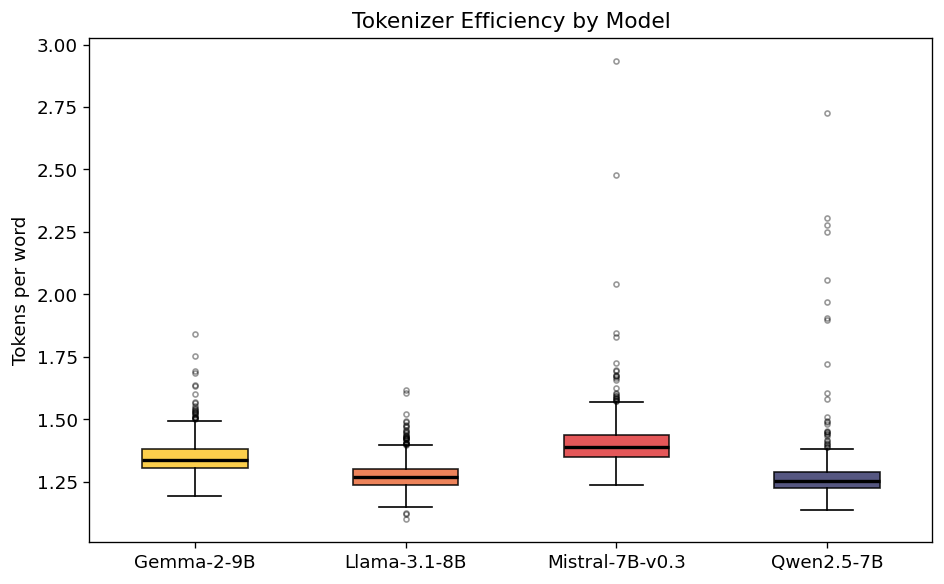

In [197]:
df_gen['tokens_per_word'] = df_gen['n_tokens'] / df_gen['word_count']
tok_summary = df_gen.groupby('model')['tokens_per_word'].agg(['mean', 'std']).reindex(GEN_ORDER).round(2)
display(tok_summary)

fig, ax = plt.subplots(figsize=(8, 5))
data = [df_gen.loc[df_gen.model == m, 'tokens_per_word'].values for m in GEN_ORDER]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=GEN_ORDER,
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, m in zip(bp['boxes'], GEN_ORDER):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.85)

ax.set_ylabel('Tokens per word')
ax.set_title('Tokenizer Efficiency by Model')
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_tokens_per_word.png', dpi=300, bbox_inches='tight')
plt.show()

## Prompt Length vs. Story Length

Pearson r(prompt length, story length) by model:
model
Gemma-2-9B         0.14
Llama-3.1-8B       0.04
Mistral-7B-v0.3    0.07
Qwen2.5-7B         0.14
dtype: float64


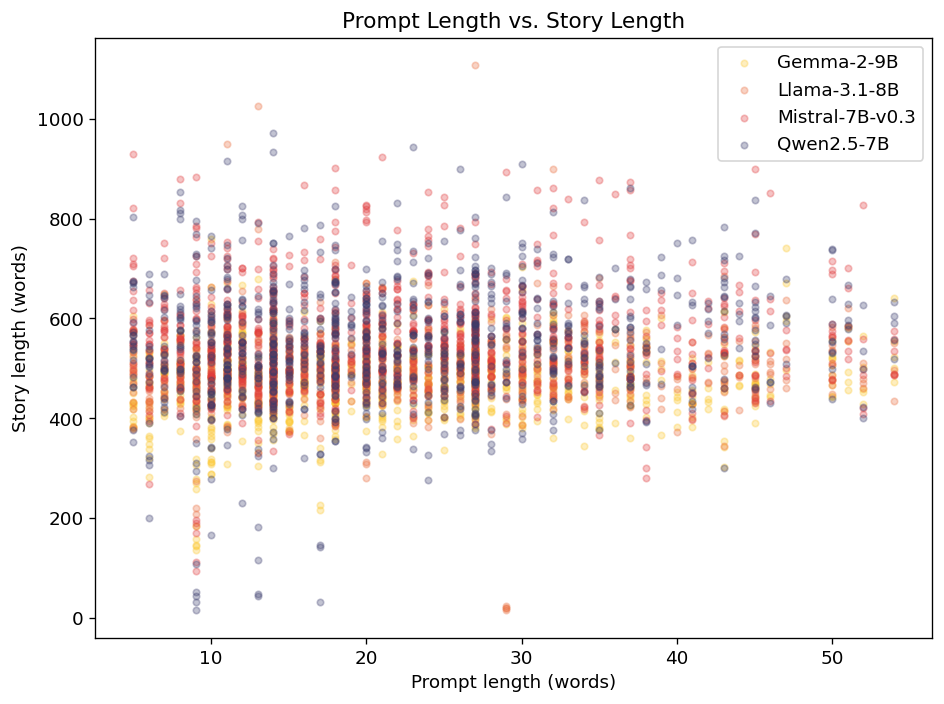

In [ ]:
human_prompt_lengths = df_human[['prompt_id', 'prompt_word_count']].drop_duplicates('prompt_id')
merged = df_gen.merge(human_prompt_lengths, on='prompt_id')
corr_by_model = merged.groupby('model').apply(lambda g: g['prompt_word_count'].corr(g['word_count'])).reindex(GEN_ORDER)


print('Pearson r(prompt length, story length) by model:')
print(corr_by_model.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
for m in GEN_ORDER:
    sub = merged[merged.model == m]
    ax.scatter(sub['prompt_word_count'], sub['word_count'], alpha=0.3, s=15,
               color=MODEL_COLORS[m], label=m)
ax.set_xlabel('Prompt length (words)')
ax.set_ylabel('Story length (words)')
ax.set_title('Prompt Length vs. Story Length')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_prompt_vs_story_length.png', dpi=300, bbox_inches='tight')
plt.show()

## Qualitative Sample: One Prompt Across All Models

In [199]:
example_ids = ['wp_0000', 'wp_0099', 'wp_0007']

for example_id in example_ids:
    n_human_refs = (df_human.prompt_id == example_id).sum()
    print(f'{"="*80}\nPROMPT_ID: {example_id}  ({n_human_refs} human references available, showing 1)')
    print('PROMPT:', df_human.loc[df_human.prompt_id == example_id, 'prompt'].iloc[0])
    print()

    for key, label in MODEL_LABELS.items():
        if key == 'human':
            story = df_human.loc[df_human.prompt_id == example_id, 'story'].iloc[0]
        else:
            story = df_gen.loc[(df_gen.model_key == key) & (df_gen.prompt_id == example_id)
                                & (df_gen.sample_idx == 0), 'story'].iloc[0]
        print(f'--- {label} ({len(story.split())} words) ---')
        print(story[:400] + ('...' if len(story) > 400 else ''))
        print()
    print()

PROMPT_ID: wp_0000  (6 human references available, showing 1)
PROMPT: Turns out that the purpose of life is war. Humans are self-multiplying shock troops, left to our own until our numbers get high enough to be useful in the ongoing galactic war. Today our previously thought to be useless DNA has been flipped to ON.

--- Gemma-2-9B (391 words) ---
The news came in a government broadcast, chilling and unavoidable. No time for dissent, no room for debate. We were not meant for this planet. Not truly. We were, in the words of the stoic, emotionless announcer, "galactic shock troops, dormant until activation." 

The activation, it turned out, wasn't some future event, some technological marvel. It was already here, a flip of a switch in our DNA...

--- Llama-3.1-8B (436 words) ---
The dreams. They'd started a few days ago, vague at first, but growing more intense with each passing night. I'd wake up to the feeling of something stirring, a low hum in the pit of my stomach. My body felt... d

## Summary

In [202]:
summary = length_summary.copy()
summary['truncated_%'] = quality_df['truncated_%'].reindex(MODEL_ORDER)
summary['non_english_%'] = lang_tab['non_english_%']
summary['exact_dup_%'] = dup_pct

summary.to_csv(FIG_DIR / 'storytelling_summary_stats.csv')
display(summary)

,count,mean,median,std,min,max,truncated_%,non_english_%,exact_dup_%
model,,,,,,,,,
Human,1880,543.1,452.0,367.3,100,2160,NaN,0.11,0.05
Gemma-2-9B,1000,474.3,475.0,70.6,137,760,0.0,0.00,0.00
Llama-3.1-8B,996,497.4,494.0,71.3,15,1108,0.4,0.00,0.00
Mistral-7B-v0.3,985,562.0,551.0,104.5,94,929,1.5,0.00,0.00
Qwen2.5-7B,992,546.5,542.0,118.5,16,972,0.3,0.60,0.00
